<h2 align="center">How Does Salary Vary by Job Title? (US)</h2>

In [2]:
# importing the libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# sorting by date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# now we will filter data for US job postings only
df_US = df[df['job_country']=='United States'].dropna(subset='salary_year_avg')

# getting the job titles
job_titles = df_US['job_title_short'].value_counts().index[:5].to_list()

# filtering for top 5 job titles
job_top_5 = df_US[df_US['job_title_short'].isin(job_titles)]

# ordering the job titles according the median average salary
job_ordered = job_top_5.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
job_ordered


Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Data Analyst'],
      dtype='object', name='job_title_short')

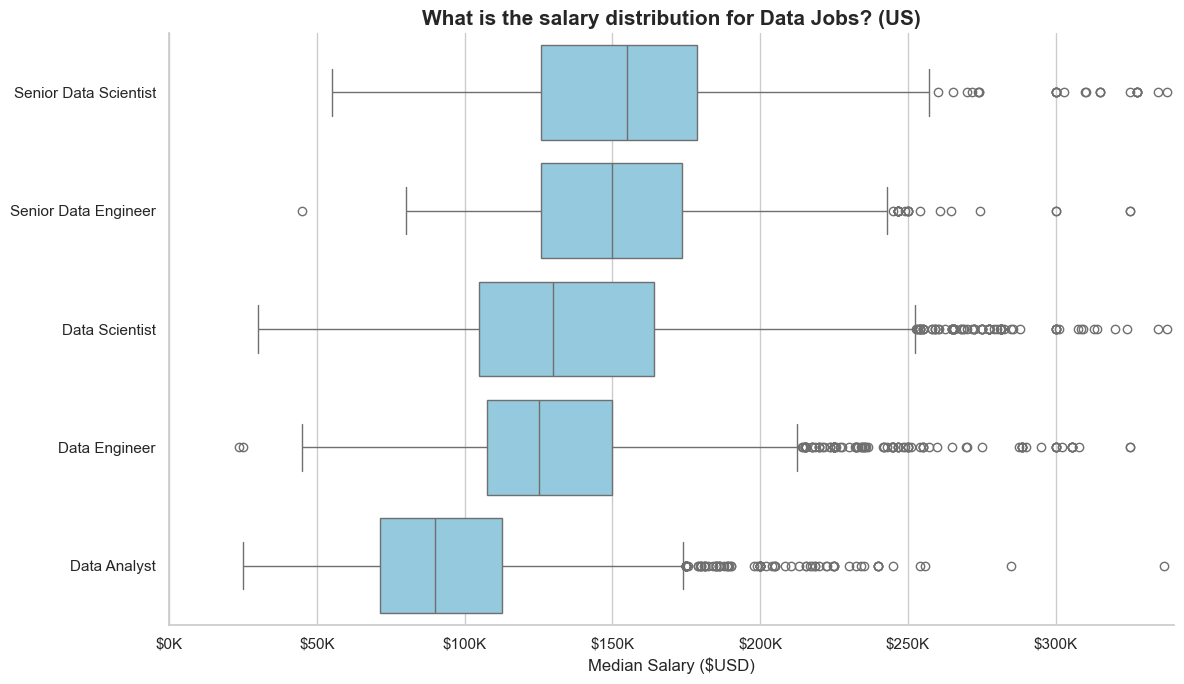

In [5]:
# final plotting
import matplotlib.ticker as mticker
from numpy import place
fig, ax = plt.subplots(figsize=(12,7))
sns.set_theme(style='whitegrid')
sns.boxplot(data=job_top_5,x='salary_year_avg',y='job_title_short',order=job_ordered,color='skyblue')

# lets format the plot
plt.title('What is the salary distribution for Data Jobs? (US)',fontsize=15,fontweight='bold')
plt.xlabel('Median Salary ($USD)')
plt.ylabel('')
plt.xlim(0,340000)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# remove extra borders
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)


plt.tight_layout()
plt.show()